In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/brendan45774/test-file/tested.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r'/kaggle/input/datasets/brendan45774/test-file/tested.csv')

**UNDERSTANDING DATA**

In [4]:
df.sort_values('Fare')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
372,1264,0,1,"Ismay, Mr. Joseph Bruce",male,49.0,0,0,112058,0.0000,B52 B54 B56,S
266,1158,0,1,"Chisholm, Mr. Roderick Robert Crispin",male,NaN,0,0,112051,0.0000,NaN,S
21,913,0,3,"Olsen, Master. Artur Karl",male,9.0,0,1,C 17368,3.1708,NaN,S
133,1025,0,3,"Thomas, Mr. Charles P",male,NaN,1,0,2621,6.4375,NaN,C
116,1008,0,3,"Thomas, Mr. John",male,NaN,0,0,2681,6.4375,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...,...
375,1267,1,1,"Bowen, Miss. Grace Scott",female,45.0,0,0,PC 17608,262.3750,NaN,C
53,945,1,1,"Fortune, Miss. Ethel Flora",female,28.0,3,2,19950,263.0000,C23 C25 C27,S
69,961,1,1,"Fortune, Mrs. Mark (Mary McDougald)",female,60.0,1,4,19950,263.0000,C23 C25 C27,S
343,1235,1,1,"Cardeza, Mrs. James Warburton Martinez (Charlo...",female,58.0,0,1,PC 17755,512.3292,B51 B53 B55,C


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:

df["Pclass"].nunique()

3

In [7]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [9]:
df.rename(columns={"Sex":"Gender","Pclass":"Passenger_class"},inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      418 non-null    int64  
 1   Survived         418 non-null    int64  
 2   Passenger_class  418 non-null    int64  
 3   Name             418 non-null    object 
 4   Gender           418 non-null    object 
 5   Age              332 non-null    float64
 6   SibSp            418 non-null    int64  
 7   Parch            418 non-null    int64  
 8   Ticket           418 non-null    object 
 9   Fare             417 non-null    float64
 10  Cabin            91 non-null     object 
 11  Embarked         418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [11]:
df.describe()

,PassengerId,Survived,Passenger_class,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [12]:
df["Cabin"]=df["Cabin"].fillna("Missing")

In [13]:
df.isnull().sum()

PassengerId         0
Survived            0
Passenger_class     0
Name                0
Gender              0
Age                86
SibSp               0
Parch               0
Ticket              0
Fare                1
Cabin               0
Embarked            0
dtype: int64

In [14]:
gp = df.groupby("Gender").agg({"Age":"mean"})

male_Age = gp.loc["male","Age"]
female_Age = gp.loc["female","Age"]

df.loc[df['Gender']=="male","Age"] = df.loc[df['Gender']=="male","Age"].fillna(male_Age)
df.loc[df['Gender']=="female","Age"] = df.loc[df['Gender']=="female","Age"].fillna(female_Age)

In [15]:
df["Fare"]=df["Fare"].fillna(df["Fare"].mean())

In [16]:
df["Cabin"]=df["Cabin"].fillna("Unknown")

In [17]:
gp=df.groupby("Gender")["Age"].mean().round(2)
X=gp.loc["male"]
Y=gp.loc["female"]
print("Average Age of Male : ",X)
print("Average Age of Female : ",Y)

Average Age of Male :  30.27
Average Age of Female :  30.27


In [18]:
gs=df.groupby("Gender")["Fare"].sum().round(2)
print("Total Fare of Male : ",gs.loc['male'])
print("Total Fare of Female :",gs.loc['female'])
print("Total Fare of Titanic : ",gs.loc['male']+gs.loc['female'])

Total Fare of Male :  7330.51
Total Fare of Female : 7561.65
Total Fare of Titanic :  14892.16


In [19]:
pd.crosstab(df["Gender"], df["Survived"])

Survived,0,1
Gender,,
female,0,152
male,266,0


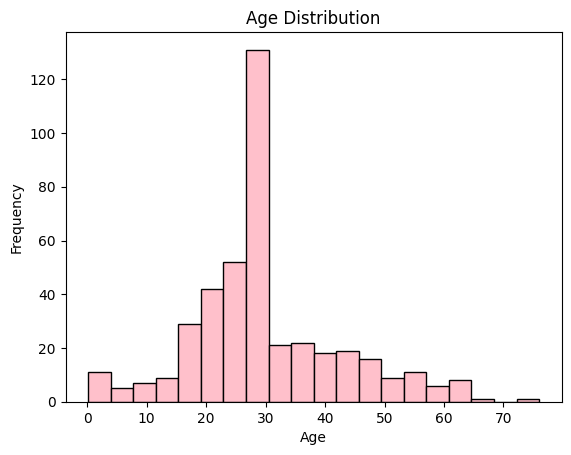

In [20]:
plt.hist(df['Age'],bins=20,edgecolor="Black",color="pink")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

**MOST OF THE PEOPLE ARE OF AGE 20-30**

<Axes: ylabel='count'>

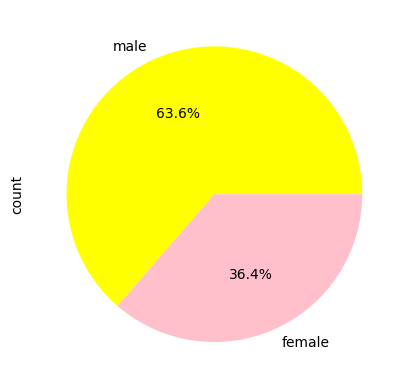

In [21]:
df["Gender"].value_counts().plot.pie(autopct="%1.1f%%",colors=["yellow","Pink"])

<Axes: xlabel='Gender'>

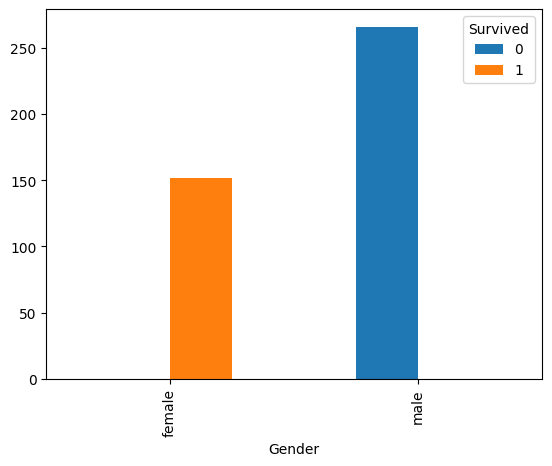

In [22]:
(pd.crosstab(df["Gender"],df["Survived"])).plot(kind="bar",stacked=False)

In [23]:
df.drop("Cabin",axis=1)

,PassengerId,Survived,Passenger_class,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.500000,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.000000,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.000000,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.000000,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.000000,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,30.272732,0,0,A.5. 3236,8.0500,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.000000,0,0,PC 17758,108.9000,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.500000,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,0,3,"Ware, Mr. Frederick",male,30.272732,0,0,359309,8.0500,S


Text(0, 0.5, 'Survived')

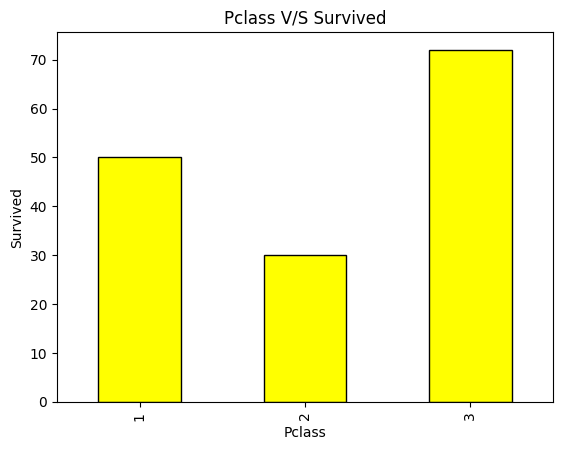

In [24]:
(df[df["Survived"]==1].groupby("Passenger_class")["Survived"].count()).plot(kind="bar",edgecolor="Black",color="yellow")
plt.title("Pclass V/S Survived")
plt.xlabel("Pclass")
plt.ylabel("Survived")

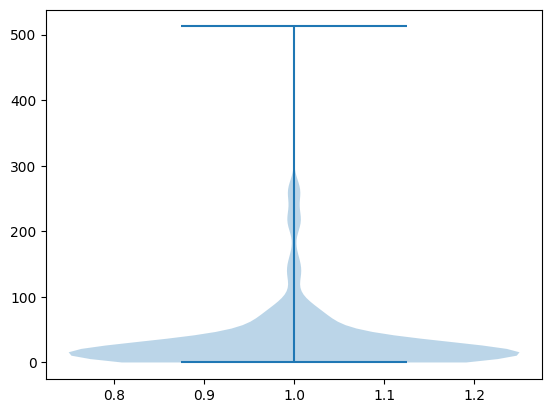

In [25]:
plt.violinplot(df['Fare'])
plt.show()
# gs

**ALMOST 90% PEOPLE PAID LESS THAN 100**

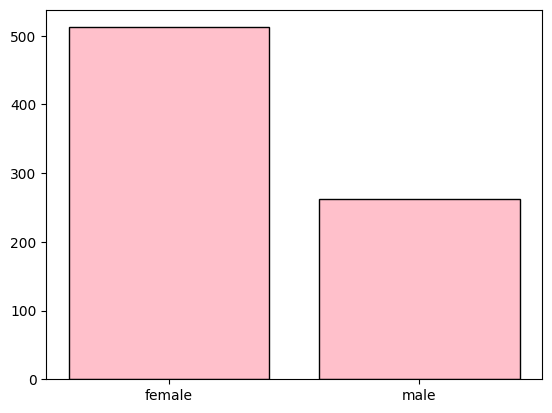

In [26]:
gs=df.groupby("Gender")["Fare"].max()
plt.bar(gs.index,gs.values,edgecolor="black",color="pink")
plt.show()


In [27]:
df.loc[df["Fare"].idxmax(),["Name","Gender"]]

Name      Cardeza, Mrs. James Warburton Martinez (Charlo...
Gender                                               female
Name: 343, dtype: object

**Highest Price For Ticket Paid by male**

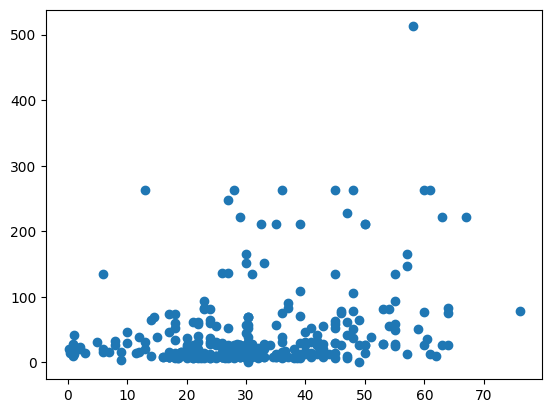

In [28]:
plt.scatter(df["Age"],df["Fare"])

**THIS HELPS US TO UNDERSTAND RELATIONSHIP BTW FARE AND AGE**

{'whiskers': [<matplotlib.lines.Line2D at 0x7c9566c87f50>,
 'caps': [<matplotlib.lines.Line2D at 0x7c9566d23230>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c95690d58b0>],
 'medians': [<matplotlib.lines.Line2D at 0x7c9566c80680>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c9566c598e0>],
 'means': []}

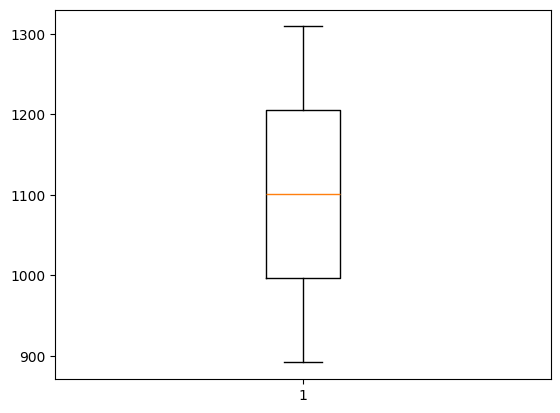

In [29]:
plt.boxplot(df["PassengerId"])

**Range of Passenger ids**